# Chapter 5 — Synthesis

One question, four chapters: *can end-to-end RL rediscover Kelly bet-sizing on blackjack's countable
edge?* The answer is **no**, and — this is the part worth keeping — we can say *exactly why*, having ruled
out the alternatives one at a time.

In [1]:
import sys; sys.path.insert(0, '.')
import pandas as pd
from blackjack_rl.analysis_loader import load_bet_evals, bet_provenance, plot_ladder_bars, show

evals = load_bet_evals()
AGENT_CFG = {"growth": {"bankroll_feature": "raw"}, "ruin": {"gamma": 0.95, "double": "off"}}
fin = evals[(evals.phase == "final") & (evals.regime == evals.train_regime)]

## 5.1 The one-line result

**Only Kelly beats Flat — and only barely.** In the growth regime the analytic bettor clears the Flat
floor decisively (z ≈ 7), though even Kelly stays *net-negative* (it loses less, not money); in the ruin
regime its edge is real but marginal (p ≈ 0.04) and bought with more drawdown. The DQN clears the floor in
neither — it converges to ≈ Flat and, when it strays toward Kelly-shaped ramps, measures *worse* than Flat.
The scoreboard is the whole report in one figure.

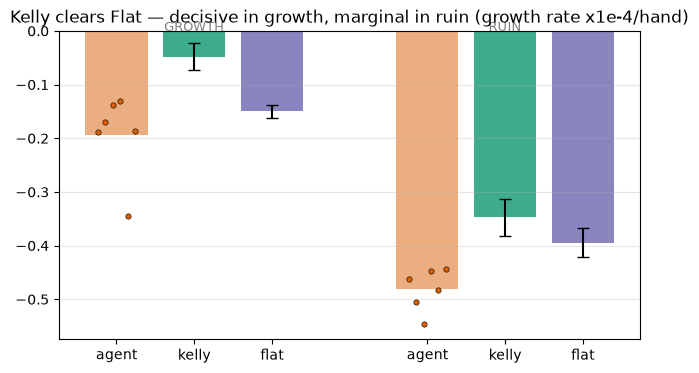

In [2]:
plot_ladder_bars(evals, "growth_1e4", AGENT_CFG, title="Kelly clears Flat — decisive in growth, marginal in ruin (growth rate x1e-4/hand)")

## 5.2 The real lesson — structured ≫ end-to-end on a sub-noise signal

The edge exists; Kelly captures it; RL cannot. The reason (Chapter 3) is that the signal is **thinner than
the per-hand noise it must be estimated through**, and the states carrying it are rare. Where a signal is
that thin, the sample efficiency of *structure* wins decisively: Kelly reads the edge from a curve we
measured once, offline, over millions of hands; the DQN must re-estimate that same curve online, through a
noisier channel, from far fewer high-count samples. Same edge, opposite sample budgets.

This is the through-line of the whole project. Problem A found the tabular/structured play policy matching
or beating the end-to-end network on the rare cells. Problem B's B2c found "the skill is restraint" — Kelly
barely beats flat, so the bettor's job is mostly *not over-betting*. Problem B here closes it: on a
sub-noise edge, **encode what you know; don't ask a value learner to rediscover it.**

## 5.3 The honesty trail

The result is only as trustworthy as the checks that survived. Three times the *first* read of the evidence was
wrong, and each time a discipline — multi-seed CIs, four-axis evaluation, or cross-seed replication — caught it. Recording these
is the point, not a footnote: the conclusion stands *because* these were caught, not in spite of them.

In [3]:
honesty = pd.DataFrame([
    {"first read (tempting)": "double-DQN looked 'safe' (low drawdown)",
     "the check that caught it": "multi-seed CIs (not one run)",
     "corrected finding": "seed-luck — dd 2.6 +/- 3.05, unstable across seeds"},
    {"first read (tempting)": "the near-Kelly ramps it visits are the real policy",
     "the check that caught it": "best-checkpoint four-axis eval (H3)",
     "corrected finding": "far worse drawdown (14-18% vs ~0.8%); no better growth"},
    {"first read (tempting)": "it keyed on wealth, not the count (embedding)",
     "the check that caught it": "OOD + cross-seed replication + encoding ablation",
     "corrected finding": "embedding is seed-specific noise; 'none' == 'raw' -> falsified"},
])
show(honesty, caption="The honesty trail — three tempting over-reads, and what caught each")

first read (tempting),the check that caught it,corrected finding
double-DQN looked 'safe' (low drawdown),multi-seed CIs (not one run),"seed-luck — dd 2.6 +/- 3.05, unstable across seeds"
the near-Kelly ramps it visits are the real policy,best-checkpoint four-axis eval (H3),far worse drawdown (14-18% vs ~0.8%); no better growth
"it keyed on wealth, not the count (embedding)",OOD + cross-seed replication + encoding ablation,embedding is seed-specific noise; 'none' == 'raw' -> falsified


## 5.4 What's settled, and what's next

**Settled.** The encoding question is closed (Chapter 4): representation is not the bottleneck. The verdict
is CI-backed and multi-seed. B3/B4 were cut deliberately — the interesting question was answered, and more
compute on the same design would only re-confirm ≈ Flat.

**Where a follow-up would actually aim.** Not at the encoder — at **coverage**. The unlearned states are
the rare high counts, so the levers that could move the needle target sample allocation, not capacity:

- **oversampling / stratified replay** of high-count states, so the estimate sharpens where the edge lives;
- **prioritised experience replay** keyed on TD-error (the high-count transitions carry the signal);
- and, honestly, the acknowledgement that even then the prize is 0.10e-4/hand — the structured bettor will
  remain the sample-efficient answer. The lesson isn't "try harder to learn it"; it's "know when a derived
  rule beats a learned one."

## 5.5 Close

Blackjack betting gave us something rare — a learnable task with a *known* optimum — and used it to draw a
clean line. End-to-end value learning is a powerful default, but on a thin, sub-noise, rare-state signal it
is out-sampled by structure that encodes what we already know. The agent learned restraint; we learned when
not to reach for the agent.